## KMeans - **Agrupamento de Clientes**

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import pylab

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist, pdist
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

## **Análise Exploratória**

In [93]:
dados = pd.read_csv('household_power_consumption.txt', sep=';', low_memory=False)
dados.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [94]:
dados = dados.rename(columns={'Sub_metering_1':'Cozinha', 'Sub_metering_2':'Lavanderia', 'Sub_metering_3':'Aquecedor_Ar'})

In [95]:
dados.shape

(2075259, 9)

In [96]:
dados.dtypes

Date                      object
Time                      object
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Cozinha                   object
Lavanderia                object
Aquecedor_Ar             float64
dtype: object

In [97]:
dados.isnull().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Cozinha                      0
Lavanderia                   0
Aquecedor_Ar             25979
dtype: int64

In [98]:
# Checando se há valores Nulos
dados.isnull().values.any()

np.True_

## **Pré-Processamento**

In [99]:
# Remover as Duas primeiras colunas e os valores Nulos
dados = dados.iloc[0:, 2:].dropna()

In [100]:
dados.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Cozinha,Lavanderia,Aquecedor_Ar
0,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [101]:
dados.isnull().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Cozinha                  0
Lavanderia               0
Aquecedor_Ar             0
dtype: int64

In [102]:
dados.isnull().values.any()

np.False_

In [103]:
dataset_atrib = dados.values

In [104]:
dataset, amostra = train_test_split(dataset_atrib, train_size=0.01)

In [105]:
dataset.shape

(20492, 7)

## **Máquina Preditiva**

### **PCA - Análise de Componentes Principais**

In [106]:
# Aplica a Redução de Dimensionalidade no array
pca = PCA(n_components=2).fit_transform(dataset)

In [107]:
# Criar uma Range do Hiperparâmetro do KMeans
K_range = range(1, 12)
K_range

range(1, 12)

In [108]:
# Aplicar o modelo KMeans para cada valor de K (pode demorar)
k_means_var = [KMeans(n_clusters=k).fit(pca) for k in K_range]

### **Curva de Elbow**

In [109]:
# Ajustando o centróide do cluster para cada modelo
centroids = [X.cluster_centers_ for X in k_means_var]

# Calculando a distância euclidiana de cada ponto de dado para o centróide
K_euclid = [cdist(pca, cent, 'euclidean') for cent in centroids]
dist = [np.min(ke, axis=1) for ke in K_euclid]

# Soma dos quadrados das distâncias dentro do cluster
soma_quadrados_intra_cluster = [sum(d ** 2) for d in dist]

soma_total = sum(pdist(pca) ** 2) / pca.shape[0]
# Soma total dos quadrados
soma_quadrados_intra_cluster = soma_total -soma_quadrados_intra_cluster

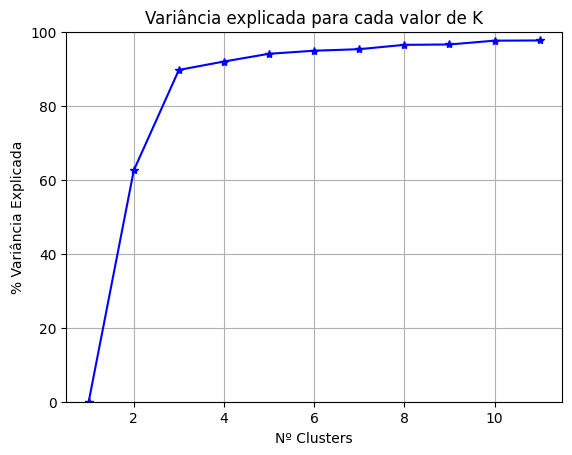

In [110]:
# Curva de Elbow
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(K_range, soma_quadrados_intra_cluster/soma_total * 100, 'b*-')
ax.set_ylim((0,100))
plt.grid(True)

plt.xlabel('Nº Clusters')
plt.ylabel('% Variância Explicada')
plt.title('Variância explicada para cada valor de K')

plt.show()

### **Escolher k inicial igual a 8 para avaliação da Máquina Preditiva**

In [116]:
modelo_v1 = KMeans(n_clusters=8)
modelo_v1.fit(pca)

KMeans()

## **Avalição da Máquina Preditiva**

In [114]:
def grafico_Elbow(modelo, X):
    # Obtém os valores mínimos e máximos e organiza o shape
    x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() - 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() - 5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, .02), np.arange(y_min, y_max, .02))

    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot das áreas dos clusters
    plt.figure(1)
    plt.clf()

    plt.imshow(Z,
            interpolation='nearest',
            extent=(xx.min(), xx.max(), yy.min(), yy.max()),
            cmap=plt.cm.Paired,
            aspect='auto',
            origin='lower')

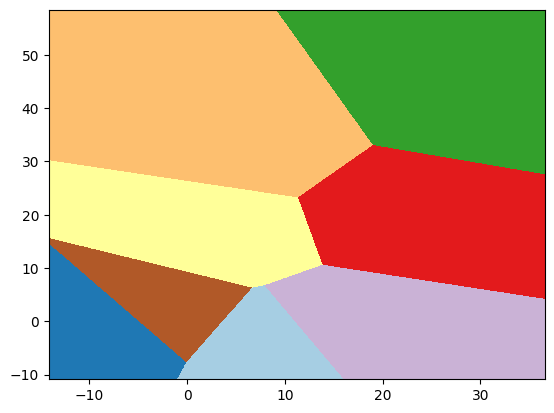

In [117]:
grafico_Elbow(modelo_v1, pca)

In [ ]:
# Métrica de Avaliação para Clusterização
?silhouette_score

In [ ]:
# Silhouette Score - o MELHOR valor é 1 e o PIOR valor é -1
labels = modelo_v1.labels_ # -> y
silhouette_score(pca, labels=labels, metric='euclidean')

np.float64(0.6773292034694666)

## **k = 8, 9, 10, 11 e 12**

In [92]:
def calc_silhouette_score(X, k):
    modelo_vk = KMeans(n_clusters=k)
    modelo_vk.fit(X)

    labels = modelo_vk.labels_

    return silhouette_score(X, labels=labels, metric='euclidean')

for i in range(8, 13):
    print('k(', i, ') :', calc_silhouette_score(pca, i))

k( 8 ) : 0.6038058339720784
k( 9 ) : 0.7592687099652519
k( 10 ) : 0.6107359161144289
k( 11 ) : 0.5984248434740436
k( 12 ) : 0.4817649511896422


### **K = 9 -> Melhor Resultado**

In [120]:
modelo = KMeans(n_clusters=9)
modelo.fit(pca)

KMeans(n_clusters=9)

## **Usando a Marcação dos Clusters da Máquina Preditiva Final**

In [126]:
# Lista com nomes das colunas
colunas = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Cozinha', 'Lavanderia', 'Aquecedor_Ar']

cluster_map                        = pd.DataFrame(dataset, columns=colunas)
cluster_map['Global_active_power'] = pd.to_numeric(cluster_map['Global_active_power'])
cluster_map['Cluster']             = modelo.labels_


In [127]:
cluster_map.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Cozinha,Lavanderia,Aquecedor_Ar,Cluster
0,1.606,0.050,239.380,6.600,0.000,0.000,17.0,5
1,0.178,0.158,243.000,0.800,0.000,0.000,1.0,0
2,1.414,0.306,240.860,6.000,0.000,0.000,19.0,5
3,0.872,0.182,240.990,3.600,0.000,0.000,0.0,0
4,1.874,0.464,235.950,8.200,0.000,2.000,17.0,1


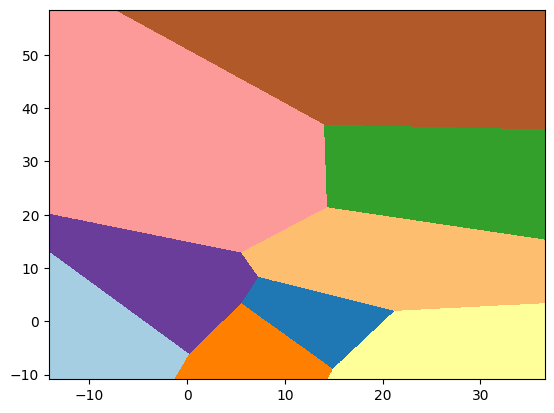

In [124]:
grafico_Elbow(modelo, pca)

In [128]:
# Calcular a Média do Consumo para cada Cluster
cluster_map.groupby('Cluster')['Global_active_power'].mean()

Cluster
0    0.380346
1    2.635753
2    4.442732
3    3.126557
4    3.753703
5    1.489389
6    1.636784
7    2.354903
8    5.798235
Name: Global_active_power, dtype: float64